In [1]:
from xymap import *

from __Global__ import *

C:\ProgramData\miniforge3\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
class plot_time_series():
    def __init__(self):
        self.map_width = 13 * centimeter_factor
        self.map_height = 8.2 * centimeter_factor

    def run(self):
        self.plot_LAIpercentile()

    def plot_LAIpercentile(self):
        df = T.load_df(result_root + rf'\Upload_Data\Figure2\time_series\\Dataframe_area_weighted.df')
        df = self.df_clean(df)
        # print(len(df))

        variable_list = ['composite_LAImax_mean',
                         'composite_LAImin_mean',

                         'composite_LAIp95_mean',
                         'composite_LAIp90_mean',
                         'composite_LAIp80_mean',
                         'composite_LAIp70_mean',
                         'composite_LAIp60_mean',

                         'composite_LAIp40_mean',
                         'composite_LAIp30_mean',
                         'composite_LAIp20_mean',
                         'composite_LAIp10_mean',
                         'composite_LAIp5_mean',

                         ]

        # variable_list = ['composite_LAImax_mean',
        #                  'composite_LAImin_mean',
        #
        #                  # 'composite_LAIp99_mean',
        #                  'composite_LAIp95_mean',
        #                  'composite_LAIp90_mean',
        #                  'composite_LAIp80_mean',
        #                  'composite_LAIp20_mean',
        #
        #                  'composite_LAIp10_mean',
        #                  'composite_LAIp5_mean',
        #                  # 'composite_LAIp1_mean',
        #
        #
        #                  ]

        dic_label = {'composite_LAImax_mean': 'LAImax',
                     'composite_LAImin_mean': 'LAImin',
                     'composite_LAIp99_mean': 'LAIp99',
                     'composite_LAIp1_mean': 'LAIp1',
                     'composite_LAIp10_mean': 'LAIp10',
                     'composite_LAIp90_mean': 'LAIp90',
                     'composite_LAIp5_mean': 'LAIp5',
                     'composite_LAIp95_mean': 'LAIp95',
                     'composite_LAIp60_mean': 'LAIp60',
                     'composite_LAIp70_mean': 'LAIp70',
                     'composite_LAIp80_mean': 'LAIp80',
                     'composite_LAIp20_mean': 'LAIp20',
                     'composite_LAIp30_mean': 'LAIp30',
                     'composite_LAIp40_mean': 'LAIp40',

                     }

        color_dic = {

            'composite_LAImax_mean': '#26269A',
            'composite_LAImin_mean': '#D23F4D',
            'composite_LAIp95_mean': '#5D4F9D',
            'composite_LAIp5_mean': '#F36A31',

            'composite_LAIp80_mean': 'teal',
            'composite_LAIp20_mean': 'lightcoral',
            'composite_LAIp60_mean': 'yellowgreen',
            'composite_LAIp70_mean': 'cyan',
            'composite_LAIp30_mean': 'olive',
            'composite_LAIp40_mean': 'gold',

            'composite_LAIp99_mean': 'blue',
            'composite_LAIp1_mean': 'red',
            'composite_LAIp10_mean': '#F8AF66',
            'composite_LAIp90_mean': '#2A85BA',

        }

        year_list = range(0, 25)
        result_dic = {}
        std_dic = {}

        # === 计算每个窗口的均值和标准差 ===
        for var in variable_list:
            mean_dic, std_dic_i = {}, {}
            for year in year_list:
                df_i = df[df['window'] == year]
                ## scheme1
                vals = np.array(df_i[f'{var}'].tolist(), dtype=float)
                weight = np.array(df_i['area_weight'].tolist(), dtype=float)
                weighted_mean_values = (
                        np.nansum(vals * weight)
                        / np.nansum(weight * np.isfinite(vals))
                )

                # print(year, weighted_mean_values)
                ## scheme2
                # vals = np.array(df_i[f'{var}'].tolist(), dtype=float)
                # weighted_mean_values = np.nanmean(vals)

                mean_dic[year] = weighted_mean_values

            result_dic[var] = mean_dic
            std_dic[var] = std_dic_i

        df_mean = pd.DataFrame(result_dic)

        # === 绘图 ===
        plt.figure(figsize=(map_width * 1.8, map_height))
        legendmap = {
            'LAImax': 'LAImax',
            'LAImin': 'LAImin',
            'LAIp99': '99th',
            'LAIp95': '95th',
            'LAIp90': '90th',
            'LAIp10': '10th',
            'LAIp5': '5th',
            'LAIp1': '1st',
            'LAIp80': '80th',
            'LAIp60': '60th',
            'LAIp40': '40th',
            'LAIp20': '20th',
            'LAIp70': '70th',
            'LAIp30': '30th',

        }

        for var in variable_list:
            color = color_dic[var]

            # 计算线和阴影区
            y = df_mean[var]
            # yerr = df_std[var]
            years = list(year_list)

            # 背景阴影 (mean ± std)
            # plt.fill_between(years,
            #                  y - yerr,
            #                  y + yerr,
            #                  color=color,
            #                  alpha=0.1)

            # 主趋势线
            plt.plot(years, y, color=color, linewidth=2,
                     label=legendmap[dic_label[var]], marker='o', markersize=5)

            # 拟合趋势线 + 注释
            slope, intercept, r_value, p_value, std_err = stats.linregress(years, y)
            # print(var, slope, p_value)
            x_pos = max(years) * 0.85
            y_pos = y.mean()
            # plt.text(x_pos, y_pos + 1.5, f'{dic_label[var]} slope={slope:.3f}', fontsize=10, color=color)
            # plt.text(x_pos, y_pos - 12, f'p={p_value:.3f}', fontsize=10, color=color)

        # === X轴标签（15年滑窗） ===
        window_size = 15
        year_range = range(1982, 2021)
        year_range_str = []
        for year in year_range:
            start_year = year
            end_year = year + window_size - 1
            if end_year > 2021:
                break
            year_range_str.append(f'{start_year}-{end_year}')

        plt.yticks(fontsize=12)
        plt.xticks(range(len(year_range_str))[::3], year_range_str[::3], rotation=45, ha='right', fontsize=12)

        plt.ylabel('Relative change(%)', fontsize=12)
        # plt.grid(alpha=0.4)
        # plt.legend(fontsize=10, loc='lower right')
        # plt.tight_layout()
        plt.show()

        # out_pdf_fdir = result_root + rf'FIGURE\\weighted_area\\'
        # T.mk_dir(out_pdf_fdir)
        # plt.savefig(out_pdf_fdir + 'time_series_LAIpercentile_SI_nolengend.pdf', dpi=300, bbox_inches='tight')
        # plt.close()

        pass

    def df_clean(self, df):
        # T.print_head_n(df)
        # df = df.dropna(subset=[self.y_variable])
        # T.print_head_n(df)
        # exit()
        df = df[df['row'] > 60]
        df = df[df['Aridity'] < 0.65]
        df = df[df['LC_max'] < 10]
        df = df[df['MODIS_LUCC'] != 12]

        df = df[df['landcover_classfication'] != 'Cropland']

        return df


class bivariate():
    def __init__(self):
        self.map_width = 13 * centimeter_factor
        self.map_height = 8.2 * centimeter_factor
    def run(self):
        self.bivariate_map()
        pass
    def bivariate_map(self):  ## figure 1  ## LAImin and LAImax bivariate
        import xymap

        fdir = result_root + rf'Upload_Data\Figure2\spatial\\\\'

        outdir = result_root + (rf'Upload_Data\\Figure\\Figure2')

        T.mkdir(outdir)

        outtif = join(outdir, 'LAImax_min_mean.tif')

        fpath1 = join(fdir, 'composite_LAImax_mean_trend.tif')

        fpath2 = join(fdir, 'composite_LAImin_mean_trend.tif')


        tif1_label, tif2_label = 'LAImax_trend', 'LAImin_trend'


        min1, max1 = -1, 1
        min2, max2 = -1, 1



        arr1 = ToRaster().raster2array(fpath1)[0]
        arr2 = ToRaster().raster2array(fpath2)[0]

        arr1[arr1 < -9999] = np.nan
        arr2[arr2 < -9999] = np.nan


        # choice 1
        upper_left_color = (0, 0, 110)
        upper_right_color = (112, 196, 181)
        lower_left_color = (237, 125, 49)

        lower_right_color = (193, 92, 156)
        center_color = (240, 240, 240)


        bivariate_plot(res=11,
                               alpha=255,
                               upper_left_color=upper_left_color,  #
                               upper_right_color=upper_right_color,  #
                               lower_left_color=lower_left_color,  #
                               lower_right_color=lower_right_color,  #
                               center_color=center_color).plot_bivariate(
            fpath1, fpath2,
            tif1_label, tif2_label,
            min1, max1,
            min2, max2,
            outtif,
            n_x=5, n_y=5
        )

        # T.open_path_and_file(outdir)

    pass

class bivariate_plot(Bivariate_plot_1):
    def __init__(self,
                 res=7,
                 alpha=200,
                 upper_left_color=(255, 202, 202),
                 upper_right_color=(148, 202, 112),
                 lower_left_color=(110, 0, 0),
                 lower_right_color=(0, 0, 110),
                 center_color=(240, 240, 240),
                 ):


        super().__init__( res=res,
                 alpha=alpha,
                 upper_left_color=upper_left_color,
                 upper_right_color=upper_right_color,
                 lower_left_color=lower_left_color,
                 lower_right_color=lower_right_color,
                 center_color=center_color,
                 )

    def plot_bivariate(
            self,tif1, tif2,
            tif1_label, tif2_label,
            min1, max1,
            min2, max2,
            outtif,
            n_x = 6, n_y = 5):


        arr_template = GDAL_func().raster2array(tif1)
        spatial_dict1 = GDAL_func().tif_to_spatial_dic(tif1)
        spatial_dict2 = GDAL_func().tif_to_spatial_dic(tif2)
        # spatial_dict1 = lytools.DIC_and_TIF(tif_template=tif1).spatial_tif_to_dic(tif1)
        # spatial_dict2 = lytools.DIC_and_TIF(tif_template=tif2).spatial_tif_to_dic(tif2)

        spatial_dict_all = {
            tif1_label: spatial_dict1,
            tif2_label: spatial_dict2
        }

        df = GDAL_func().spatial_dics_to_df(spatial_dict_all)
        df = df.dropna(how='any')
        result_arr = []
        for i in range(len(arr_template)):
            result_arr.append([])
            for j in range(len(arr_template[0])):
                result_arr[i].append([0,0,0,0])
        # x_pos = []
        # y_pos = []
        for i,row in df.iterrows():
            val1 = row[tif1_label]
            val2 = row[tif2_label]
            x = (val1 - min1) / (max1 - min1) * self.res
            y = (val2 - min2) / (max2 - min2) * self.res
            x = int(round(x, 0))
            y = int(round(y, 0))
            if x < 0:
                x = 0
            if x > self.res - 1:
                x = self.res - 1
            if y < 0:
                y = 0
            if y > self.res - 1:
                y = self.res - 1

            color = self.get_color(x, y)
            r,g,b,a = color
            r = int(r * 255)
            g = int(g * 255)
            b = int(b * 255)
            a = int(a * 255)
            color_arr = [r,g,b,a]
            # print(color)
            # exit()
            pix = row['pix']
            r,c = pix
            result_arr[r][c] = color_arr
        # outf = '/Volumes/NVME2T/China_drought_response/results/statistic/Bivariate_statistic/tif/xy_map_lag/SPEI03/bivariate.tif'
        result_arr = np.array(result_arr, dtype=np.uint8)
        plt.imshow(result_arr)
        # GDAL_func().RGBA_to_tif(result_arr, outtif,tif1)
        plt.figure(figsize=(5, 5))
        plt.imshow(self.rgb_arr[::-1])
        plt.xlabel(tif1_label)
        plt.ylabel(tif2_label)
        # plt.show()



        x_ticklabels = np.linspace(min1, max1, n_x)
        y_ticklabels = np.linspace(min2, max2, n_y)[::-1]
        x_ticklabels = np.round(x_ticklabels, 2)
        y_ticklabels = np.round(y_ticklabels, 2)
        xticks = np.linspace(0, self.res, n_x)
        yticks = np.linspace(0, self.res, n_y)

        plt.xticks(xticks, x_ticklabels)
        plt.yticks(yticks, y_ticklabels)
        plt.show()
        # outpdf = outtif.replace('.tif', '.pdf')
        # plt.savefig(outpdf)
        # plt.close()


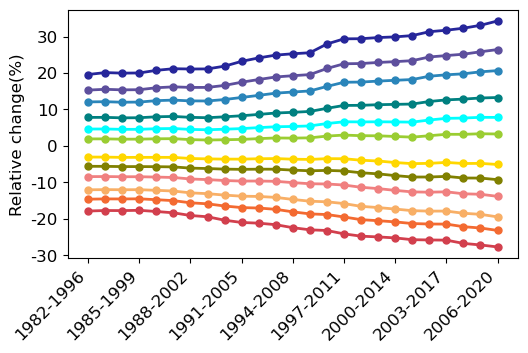

In [3]:
plot_time_series().run()

C:\ProgramData\miniforge3\Lib\site-packages\osgeo\gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


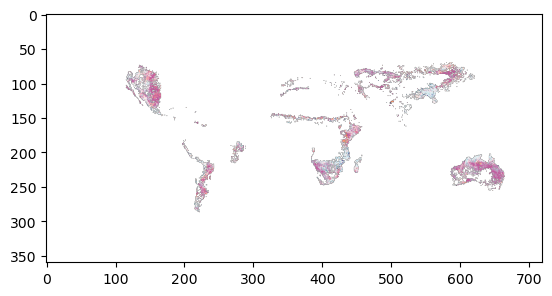

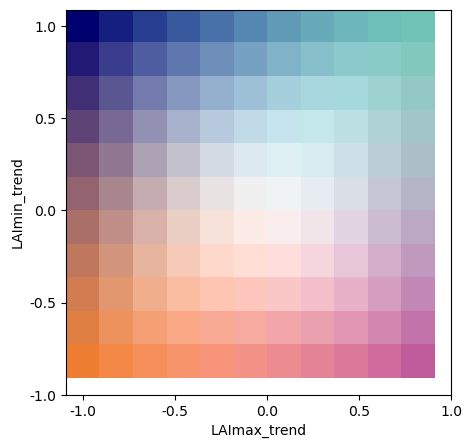

In [4]:
bivariate().run()